In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

In [2]:
df = pd.read_csv("telecom_customer_churn.csv")

In [3]:
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [5]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
num_data = ["Avg Monthly Long Distance Charges"]
cate_data = ["Offer", "Multiple Lines"]

In [8]:
num_imp = SimpleImputer(strategy = "mean")
df[num_data] = num_imp.fit_transform(df[num_data])

cate_imp = SimpleImputer(strategy = "most_frequent")
df[cate_data] = cate_imp.fit_transform(df[cate_data])

In [9]:
#Use simple imputer to fill the na values

In [10]:
internet_data = ["Internet Type", "Online Security", "Online Backup", "Device Protection Plan",
                 "Premium Tech Support", "Streaming TV", "Streaming Movies", "Streaming Music", "Unlimited Data"]
df[internet_data] = df[internet_data].fillna("No")

In [11]:
df["Avg Monthly GB Download"] = df["Avg Monthly GB Download"].fillna(0)

In [12]:
# Use fill na for internet services because all the are not get internet services so fill na values of persons who not get interenet service we use separate fill na to fill the values. in which there are no and 0 values are filled.we didnot fill the null values of churn category and churn reason because we not going to use that for our model training.

In [13]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                   0
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                        0
Internet Type                           0
Avg Monthly GB Download                 0
Online Security                         0
Online Backup                           0
Device Protection Plan                  0
Premium Tech Support                    0
Streaming TV                            0
Streaming Movies                  

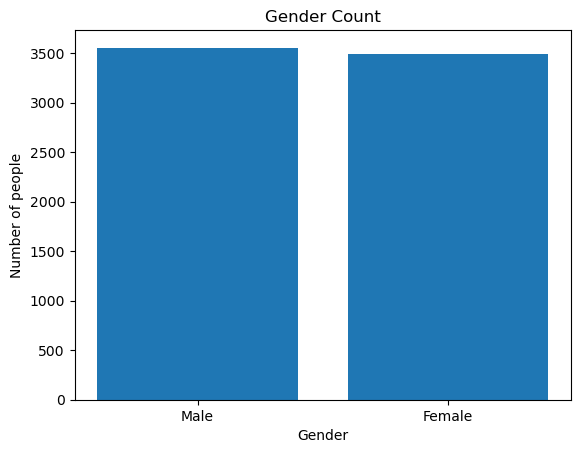

In [14]:
gender_count = df["Gender"].value_counts()

plt.bar(x = gender_count.index , height = gender_count.values)
plt.xlabel("Gender")
plt.ylabel("Number of people")
plt.title("Gender Count")
plt.show()

In [15]:
le = LabelEncoder()
df["Customer Status"] = le.fit_transform(df["Customer Status"])

In [16]:
gender_churn = df.groupby("Gender")["Customer Status"].value_counts()
gender_churn

Gender  Customer Status
Female  2                  2338
        0                   939
        1                   211
Male    2                  2382
        0                   930
        1                   243
Name: count, dtype: int64

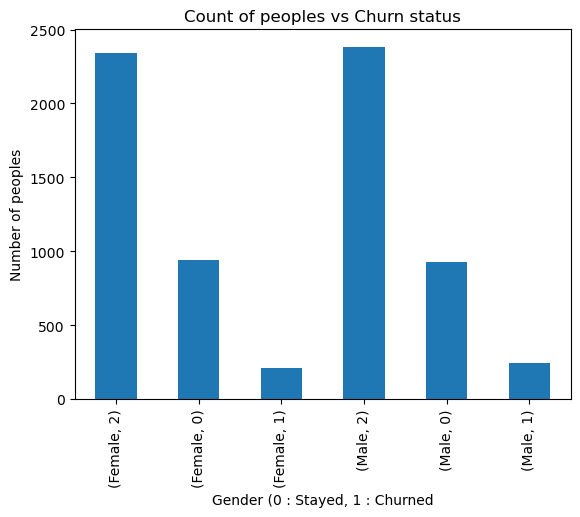

In [17]:
gender_churn.plot(kind = "bar")
plt.xlabel("Gender (0 : Stayed, 1 : Churned")
plt.ylabel("Number of peoples")
plt.title("Count of peoples vs Churn status")
plt.show()

In [18]:
internet_type_count = df["Internet Type"].value_counts()
internet_type_count

Internet Type
Fiber Optic    3035
DSL            1652
No             1526
Cable           830
Name: count, dtype: int64

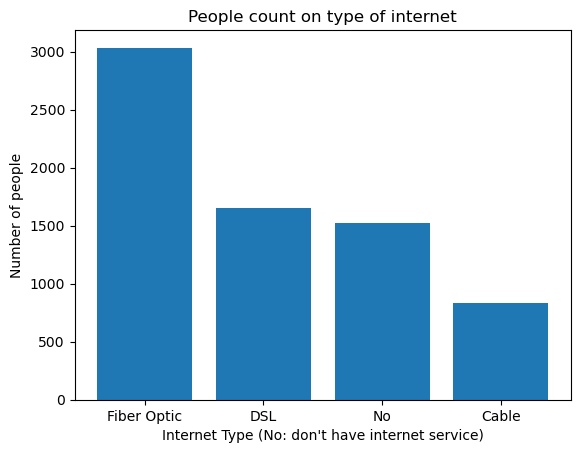

In [19]:
plt.bar(x = internet_type_count.index, height = internet_type_count.values)
plt.xlabel("Internet Type (No: don't have internet service)")
plt.ylabel("Number of people")
plt.title("People count on type of internet")
plt.show()

<Axes: xlabel='Monthly Charge', ylabel='Count'>

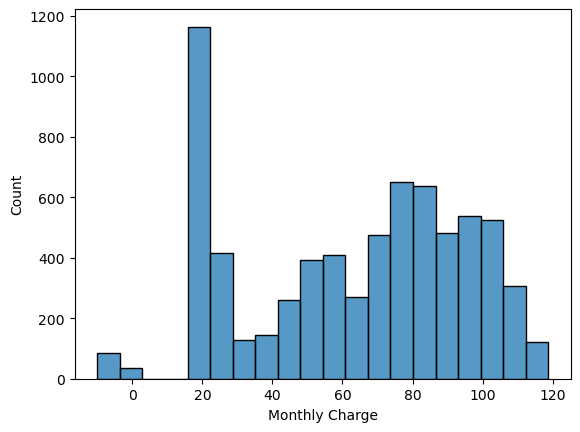

In [20]:
sns.histplot(
    df, 
    x = "Monthly Charge",
    bins = 20
)

<Axes: xlabel='Total Charges', ylabel='Count'>

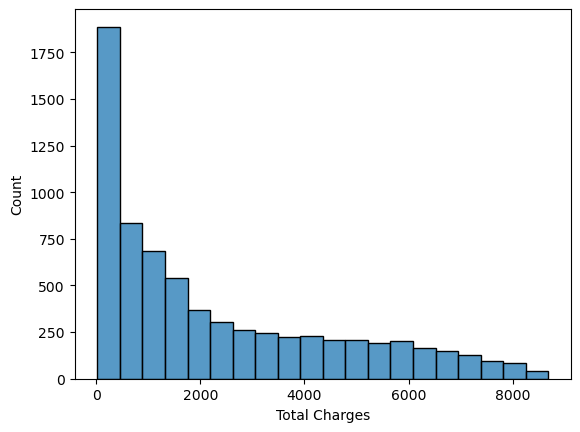

In [21]:
sns.histplot(
    df, 
    x = "Total Charges",
    bins = 20
)

In [22]:
churn_by_contract = df.groupby("Customer Status")["Contract"].value_counts()
churn_by_contract

Customer Status  Contract      
0                Month-to-Month    1655
                 One Year           166
                 Two Year            48
1                Month-to-Month     408
                 One Year            24
                 Two Year            22
2                Two Year          1813
                 Month-to-Month    1547
                 One Year          1360
Name: count, dtype: int64

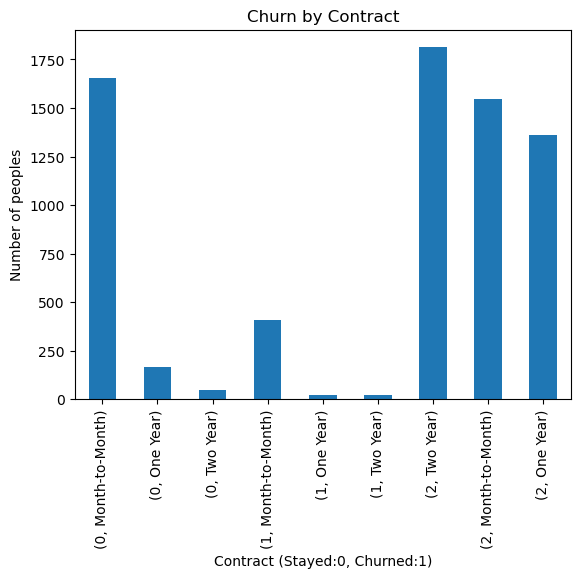

In [23]:
churn_by_contract.plot(kind = "bar")
plt.xlabel("Contract (Stayed:0, Churned:1)")
plt.ylabel("Number of peoples")
plt.title("Churn by Contract")
plt.show()

In [24]:
drop_features = ["Customer ID", "City", "Zip Code", "Latitude", "Longitude",
                 "Churn Category", "Churn Reason"]

In [25]:
df = df.drop(drop_features, axis = 1)
df1 = df.copy()

In [26]:
le_cols = ["Gender", "Married", "Phone Service", "Multiple Lines", "Internet Service", "Online Security",
          "Online Backup", "Device Protection Plan", "Premium Tech Support", "Streaming TV",
          "Streaming Music", "Unlimited Data", "Paperless Billing"]
le = LabelEncoder()
for col in le_cols:
    df[col] = le.fit_transform(df[col])

In [27]:
cols = ["Offer", "Internet Type", "Streaming Movies", "Contract", "Payment Method"]

ohe = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols), index = df.index)
df = pd.concat([df.drop(columns = cols), encoded_df], axis = 1)

In [28]:
df.head()

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,Offer_Offer D,Offer_Offer E,Internet Type_DSL,Internet Type_Fiber Optic,Internet Type_No,Streaming Movies_Yes,Contract_One Year,Contract_Two Year,Payment Method_Credit Card,Payment Method_Mailed Check
0,0,37,1,0,2,9,1,42.39,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1,46,0,0,0,9,1,10.69,1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1,50,0,0,0,4,1,33.65,0,1,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,78,1,0,1,13,1,27.82,0,1,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,75,1,0,3,3,1,7.38,0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   int64  
 1   Age                                7043 non-null   int64  
 2   Married                            7043 non-null   int64  
 3   Number of Dependents               7043 non-null   int64  
 4   Number of Referrals                7043 non-null   int64  
 5   Tenure in Months                   7043 non-null   int64  
 6   Phone Service                      7043 non-null   int64  
 7   Avg Monthly Long Distance Charges  7043 non-null   float64
 8   Multiple Lines                     7043 non-null   int64  
 9   Internet Service                   7043 non-null   int64  
 10  Avg Monthly GB Download            7043 non-null   float64
 11  Online Security                    7043 non-null   int64

In [30]:
X = df.drop("Customer Status", axis = 1)
y = df["Customer Status"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [32]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter = 1000))
])
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy score: ", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test,y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy score:  0.8197303051809794
Classification report:
               precision    recall  f1-score   support

           0       0.67      0.68      0.67       373
           1       0.66      0.68      0.67        97
           2       0.90      0.89      0.89       939

    accuracy                           0.82      1409
   macro avg       0.74      0.75      0.75      1409
weighted avg       0.82      0.82      0.82      1409

Confusion matrix:
 [[254  30  89]
 [ 27  66   4]
 [100   4 835]]


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 501,
    oob_score = True
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy score: ", accuracy_score(y_test, y_pred)*100, "%")
print("OOB score: ", rf.oob_score_ * 100, "%")
print("Classification report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy score:  82.54080908445705 %
OOB score:  84.04330848420305 %
Classification report:
               precision    recall  f1-score   support

           0       0.71      0.58      0.64       373
           1       0.68      0.59      0.63        97
           2       0.87      0.95      0.91       939

    accuracy                           0.83      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.82      0.83      0.82      1409

Confusion Matrix:
 [[218  27 128]
 [ 40  57   0]
 [ 51   0 888]]


In [34]:
depths = [3, 4, 5, 6, 7, 8, 9, 10]

for depth in depths:
    dtc = DecisionTreeClassifier(max_depth = depth)
    dtc.fit(X_train, y_train)

    y_pred = dtc.predict(X_test)
    print(f"Accuracy score for depth {depth}: ", accuracy_score(y_test, y_pred))
    print(f"Classification report for depth {depth}:\n", classification_report(y_test,y_pred))
    print(f"Confusion matrix for depth {depth}:\n", confusion_matrix(y_test, y_pred))
    print("----")

Accuracy score for depth 3:  0.7622427253371186
Classification report for depth 3:
               precision    recall  f1-score   support

           0       0.63      0.25      0.36       373
           1       0.70      0.43      0.54        97
           2       0.78      1.00      0.88       939

    accuracy                           0.76      1409
   macro avg       0.70      0.56      0.59      1409
weighted avg       0.74      0.76      0.72      1409

Confusion matrix for depth 3:
 [[ 93  18 262]
 [ 55  42   0]
 [  0   0 939]]
----
Accuracy score for depth 4:  0.7970191625266146
Classification report for depth 4:
               precision    recall  f1-score   support

           0       0.69      0.42      0.52       373
           1       0.73      0.46      0.57        97
           2       0.82      0.98      0.89       939

    accuracy                           0.80      1409
   macro avg       0.75      0.62      0.66      1409
weighted avg       0.78      0.80      0.77

In [35]:
#Best Model 
X = df1.drop("Customer Status", axis = 1)
y = df1["Customer Status"]

binary_cols = ["Gender", "Married", "Phone Service", "Multiple Lines", "Internet Service", "Online Security",
          "Online Backup", "Device Protection Plan", "Premium Tech Support", "Streaming TV",
          "Streaming Music", "Unlimited Data", "Paperless Billing"]

ohe_cols = ["Offer", "Internet Type", "Streaming Movies", "Contract", "Payment Method"]

num_cols = [col for col in X.columns if col not in binary_cols + ohe_cols]

process = ColumnTransformer(
    transformers = [
        ("bin", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), binary_cols),
        ("ohe", OneHotEncoder(drop = "first", handle_unknown = "ignore"), ohe_cols),
        ("num", "passthrough", num_cols)
    ]
)

pipeline = ImbPipeline([
    ("process", process),
    ("rfc", RandomForestClassifier(
        n_estimators = 501,
        oob_score = True
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

pipeline.fit(X_train, y_train)

model_data = {"pipeline": pipeline}

with open("pipeline.pkl", "wb") as f:
    pickle.dump(model_data, f)